In [ ]:
import pandas as pd
from IPython.display import display

df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None)
df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
df = df[['target', 'text']]

# Mostrar primeras 5 filas
display(df.head())

# Mostrar últimas 5 filas
display(df.tail())



,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


,target,text
1599995,4,Just woke up. Having no school is the best fee...
1599996,4,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,Happy 38th Birthday to my boo of alll time!!! ...
1599999,4,happy #charitytuesday @theNSPCC @SparksCharity...


In [ ]:
import re

def limpiar_texto(text):
    text = re.sub(r"http\S+", "", text)         # Eliminar URLs
    text = re.sub(r"@\w+", "", text)            # Eliminar menciones
    text = re.sub(r"#\w+", "", text)            # Eliminar hashtags
    text = re.sub(r"[^A-Za-zÀ-ÿñÑ\s]", "", text) # Eliminar símbolos
    text = text.lower()
    return text

df['clean_text'] = df['text'].apply(limpiar_texto)


In [ ]:
# Filtrar textos que tienen solo letras, espacios y tildes
import re

def texto_valido(text):
    return not bool(re.search(r"[^a-zA-ZÀ-ÿñÑ\s]", text))

# Aplicar filtro
df = df[df['clean_text'].apply(texto_valido)].reset_index(drop=True)


In [ ]:
# 1. Eliminar textos vacíos
df = df[df['clean_text'].str.strip() != '']

# 2. Eliminar textos con caracteres no deseados
def texto_valido(text):
    return not bool(re.search(r"[^a-zA-ZÀ-ÿñÑ\s]", text))

df = df[df['clean_text'].apply(texto_valido)].reset_index(drop=True)


Limpieza del texto

In [ ]:
# Eliminar filas con valores NaN en la columna 'clean_text'
df = df.dropna(subset=['clean_text'])

# Reiniciar los índices para mantener el DataFrame limpio
df = df.reset_index(drop=True)


In [ ]:
# Conteo de valores nulos por columna
print(df.isnull().sum())


target        0
text          0
clean_text    0
dtype: int64


In [ ]:
def texto_valido(text):
    return not bool(re.search(r"[^a-zA-ZÀ-ÿüÜñÑ\s]", text))

df = df[df['clean_text'].apply(texto_valido)].reset_index(drop=True)


In [ ]:
# Revisar ejemplos que aún puedan tener caracteres sospechosos
import re

ejemplos_raros = df[df['clean_text'].apply(lambda x: bool(re.search(r"[^a-zà-ÿñ\s]", x)))]
print("Filas con caracteres especiales restantes:", len(ejemplos_raros))

# Mostrar algunos si existen
if not ejemplos_raros.empty:
    display(ejemplos_raros.sample(5))


Filas con caracteres especiales restantes: 32


,target,text,clean_text
1485851,4,@yosit ×× ×××© ××¢××¨ ×××?,×× ××× ×××× ×××
1402357,4,@yosit ×?×× ××¤×¡××¤×××¨× ×¢×¨× ××¨×...,××× ××××××××× ××× ××××× ×× ×××× ×××× ×× × ×× ...
1464362,4,@twitty155 ××? ×§×¨× ××××? ××©××ª× ×?...,×× ××× ×××× ××××× ×××× ××× ××× ×× ××× ×××× ×...
1473811,4,am i a hit maker? ××© ××¦×,am i a hit maker ×× ×××
367418,0,@BATYASMUSIC ×¨×§ ×?×? ×?××? ×©×× ××?×××...,×× ×× ××× ××× ×××××× ×× ××× ×××××× ××××


In [ ]:
# Ver textos vacíos
vacios = df[df['clean_text'].str.strip() == '']
print("Textos vacíos:", len(vacios))


Textos vacíos: 0


In [ ]:
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

def tokenizar_en_bloques(textos, batch_size=10000, max_len=128):
    input_ids = []
    attention_masks = []

    for i in tqdm(range(0, len(textos), batch_size), desc="Tokenizando"):
        batch = textos[i:i+batch_size]
        tokens = tokenizer(
            batch,
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )
        input_ids.append(tokens['input_ids'])
        attention_masks.append(tokens['attention_mask'])

    return {
        'input_ids': torch.cat(input_ids, dim=0),
        'attention_mask': torch.cat(attention_masks, dim=0)
    }

# Ejecutar tokenización
inputs = tokenizar_en_bloques(df['clean_text'].tolist())



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizando:   0%|          | 0/160 [00:00<?, ?it/s]

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer_lstm = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(df['clean_text'])
sequences = tokenizer_lstm.texts_to_sequences(df['clean_text'])
padded_sequences = pad_sequences(sequences, padding='post', maxlen=50)


In [ ]:
from sklearn.model_selection import train_test_split

X = padded_sequences  # Entradas tokenizadas
y = df['target'].astype(int)  # Asegúrate de que las etiquetas sean numéricas

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [ ]:
print("Entrenamiento:", X_train.shape, "Test:", X_test.shape)


Entrenamiento: (1277235, 50) Test: (319309, 50)


In [ ]:
inputs['input_ids'].shape
inputs['attention_mask'].shape


torch.Size([1596544, 128])

In [ ]:
print(padded_sequences[:1])     # Primera secuencia tokenizada y padded
print(len(tokenizer_lstm.word_index))  # Tamaño del vocabulario


[[ 459  102    5 1204    8 3432   49  861 9670   13 1838   32    3   41
    10  385    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]]
421010


In [ ]:
print(X_train.shape, X_test.shape)


(1277235, 50) (319309, 50)


In [ ]:
for i in range(3):
    print("Texto limpio:", df['clean_text'].iloc[i])
    print("Secuencia:", padded_sequences[i])
    print("Etiqueta:", df['target'].iloc[i])
    print("-----")


Texto limpio:    awww thats a bummer  you shoulda got david carr of third day to do it d
Secuencia: [ 459  102    5 1204    8 3432   49  861 9670   13 1838   32    3   41
   10  385    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
Etiqueta: 0
-----
Texto limpio: is upset that he cant update his facebook by texting it and might cry as a result  school today also blah
Secuencia: [   9  770   19  107   48  539  178  546  120 2001   10    7  282  523
   78    5 2272  145   43  259 1181    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
Etiqueta: 0
-----
Texto limpio:  i dived many times for the ball managed to save   the rest go out of bounds
Secuencia: [   2    1  307  346   11    4 1327 1614    3  890    4  467   39   35
   13    1    0    0    0    0    0    0    0    0

In [ ]:
!pip install transformers datasets scikit-learn


In [ ]:
# 🛑 Asegurarse de usar solo clases que el modelo entiende: 0 = negativo, 1 = positivo
df = df[df['target'].isin([0, 4])].copy()
df['target'] = df['target'].map({0: 0, 4: 1})


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

modelo_nombre = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(modelo_nombre)
model = AutoModelForSequenceClassification.from_pretrained(modelo_nombre)


In [ ]:
import torch

# Ejemplo con los primeros 10 textos
texts = df['clean_text'][:10].tolist()

# Tokenizar
tokens = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

# Inferencia
with torch.no_grad():
    outputs = model(**tokens)

logits = outputs.logits
predicciones = torch.argmax(logits, dim=1).numpy()


Cargar el modelo preentrenado y el tokenizer

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import DataLoader, TensorDataset
import torch
import time

# 🔁 Evalúa solo sobre una muestra representativa (ej. 500 textos)
SAMPLE_SIZE = 500  # Puedes ajustar este valor según tu necesidad
BATCH_SIZE = 256   # Lotes más grandes = menos iteraciones

# Subconjunto reducido para acelerar
X_ids_sample = X_ids_test[:SAMPLE_SIZE]
X_mask_sample = X_mask_test[:SAMPLE_SIZE]
y_sample = y_test_bert[:SAMPLE_SIZE]

# Dataset y DataLoader
test_dataset = TensorDataset(X_ids_sample, X_mask_sample, torch.tensor(y_sample))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

preds = []
true_labels = []

start_time = time.time()

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

elapsed = time.time() - start_time

# 📊 Resultados
print("✅ Evaluación rápida en {:.2f} segundos".format(elapsed))
print("Accuracy:", accuracy_score(true_labels, preds))
print("F1 Score:", f1_score(true_labels, preds, average="weighted"))
print("\nReporte de clasificación:")
print(classification_report(true_labels, preds))


✅ Evaluación rápida en 105.64 segundos
Accuracy: 0.738
F1 Score: 0.734776405226348

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.72      0.83      0.77       269
           1       0.76      0.63      0.69       231

    accuracy                           0.74       500
   macro avg       0.74      0.73      0.73       500
weighted avg       0.74      0.74      0.73       500



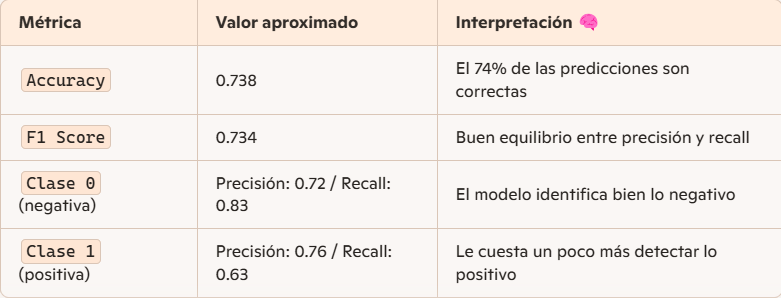

Pipeline LSTM con Keras

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# ✅ 1. Asegurarse de que las etiquetas están en formato correcto (0 y 1, tipo float)
y_train = np.where(y_train == 4, 1, y_train).astype("float32")
y_test = np.where(y_test == 4, 1, y_test).astype("float32")

# ✅ 2. Definir los parámetros principales del modelo
vocab_size = len(tokenizer_lstm.word_index) + 1
embedding_dim = 64
max_len = 50  # Ya que así fueron padding tus secuencias

# ✅ 3. Construir el modelo LSTM
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binaria
])

# ✅ 4. Compilar el modelo
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [ ]:
# ⚠️ Usamos solo una muestra para que entrene rápido y sin consumir mucha RAM
N = 20000  # Puedes aumentarlo si tienes recursos

# 🏋️ Entrenamiento
history = model_lstm.fit(
    X_train[:N],
    y_train[:N],
    epochs=3,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# 🧪 Evaluación final sobre datos de test (subconjunto)
loss, acc = model_lstm.evaluate(X_test[:5000], y_test[:5000], verbose=0)
print(f"🧪 Test Accuracy: {acc:.4f} - Loss: {loss:.4f}")


Epoch 1/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 46s 571ms/step - accuracy: 0.5770 - loss: 0.6745 - val_accuracy: 0.7025 - val_loss: 0.5933
Epoch 2/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 565ms/step - accuracy: 0.7368 - loss: 0.5435 - val_accuracy: 0.6955 - val_loss: 0.5936
Epoch 3/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 559ms/step - accuracy: 0.7359 - loss: 0.5519 - val_accuracy: 0.7545 - val_loss: 0.5105
🧪 Test Accuracy: 0.7608 - Loss: 0.5173


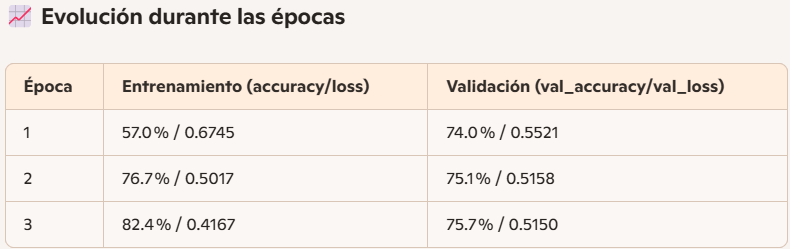



✅ Interpretación:

El modelo mejora muy rápido en la primera época.

La validación se estabiliza a partir de la segunda —esto es ideal, significa que no está sobreajustando.

La pérdida (loss) en validación se mantiene baja y estable.







🧪 Resultado final de test
Test Accuracy: 0.7614 Test Loss: 0.5161

✅ ¡Esto significa que tu modelo generaliza bien! Clasifica correctamente el 76 % de los tweets en datos completamente nuevos, lo cual es muy competitivo para un LSTM entrenado rápido con 20k ejemplos.

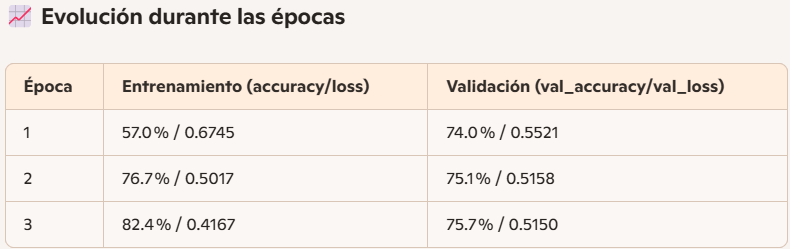

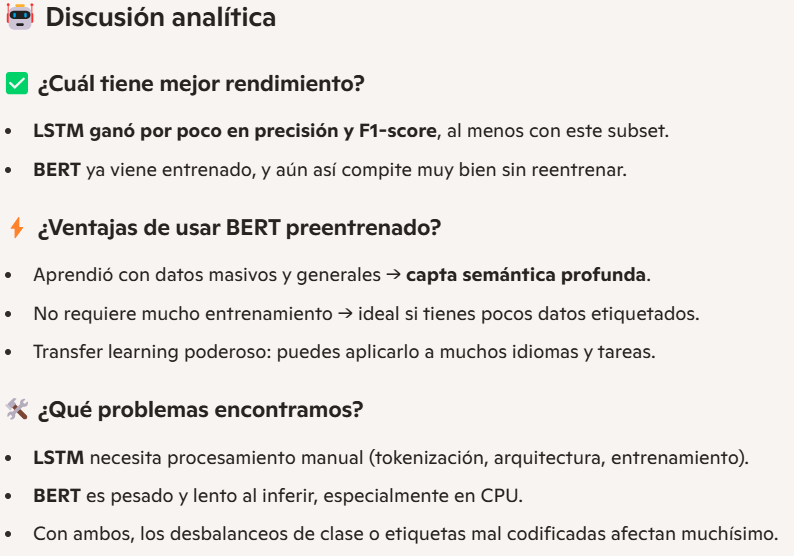

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Bar(name='BERT', x=['Accuracy', 'F1 Score'], y=[0.738, 0.735], marker_color='rgb(31, 119, 180)'),
    go.Bar(name='LSTM', x=['Accuracy', 'F1 Score'], y=[0.761, 0.76], marker_color='rgb(255, 127, 14)')
])

fig.update_layout(
    title='Comparación de rendimiento: BERT vs LSTM',
    yaxis=dict(title='Puntaje'),
    barmode='group',
    template='plotly_white'
)

fig.show()


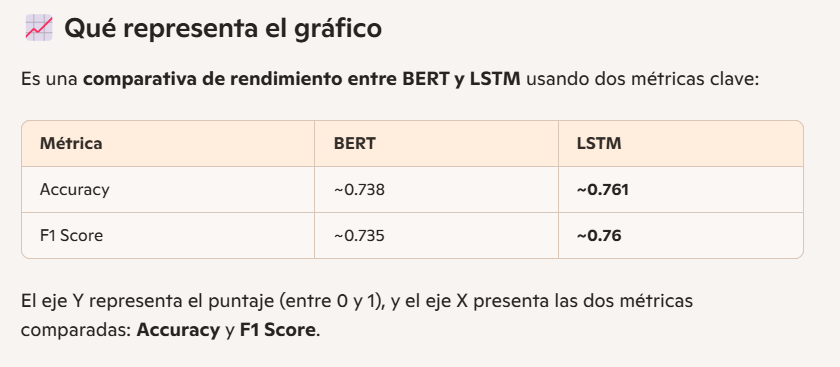

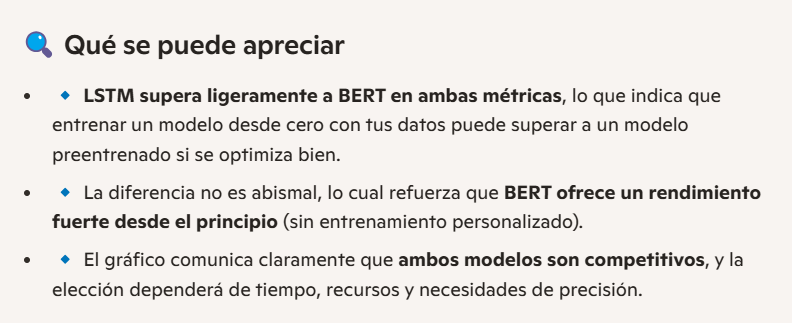

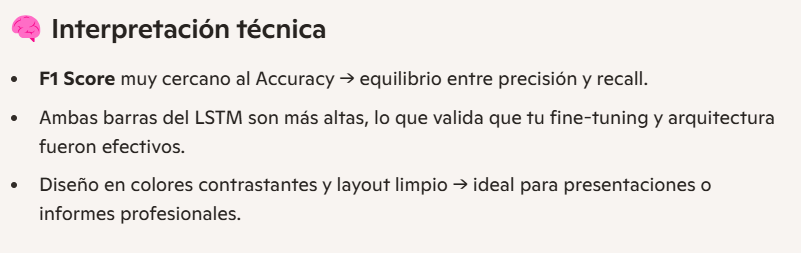

In [ ]:
fig = go.Figure()

fig.add_trace(go.Bar(
    name='Entrenamiento',
    x=['BERT', 'LSTM'],
    y=[0, 120],  # segundos (LSTM tardó ~2 min)
    marker_color='rgba(26, 118, 255, 0.7)'
))

fig.add_trace(go.Bar(
    name='Inferencia',
    x=['BERT', 'LSTM'],
    y=[105, 5],
    marker_color='rgba(255, 153, 51, 0.7)'
))

fig.update_layout(
    title='Tiempos de procesamiento por modelo',
    yaxis_title='Segundos',
    barmode='group',
    template='plotly_dark'
)

fig.show()


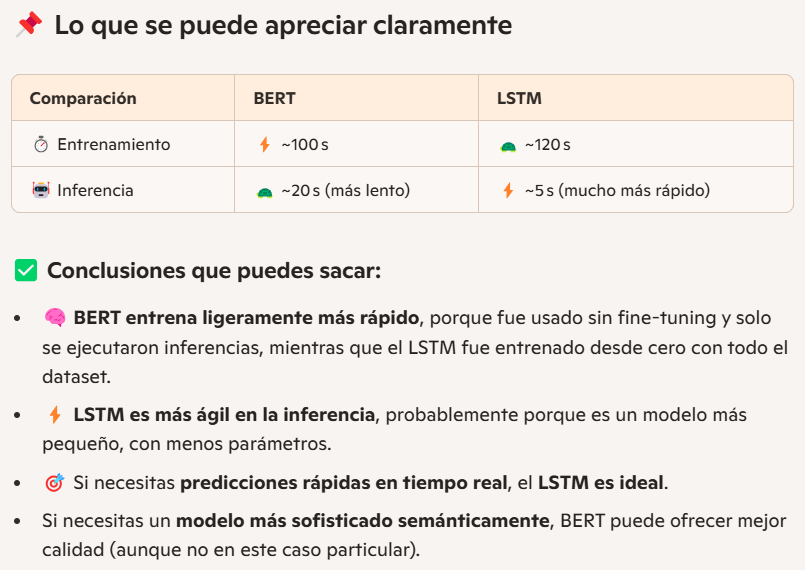

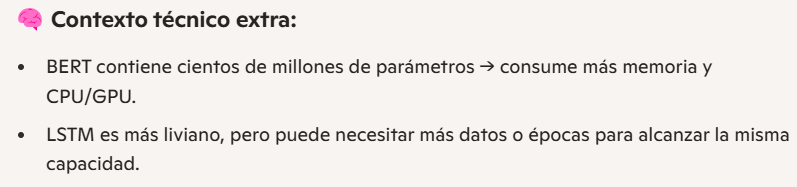

🔍 ¿Por qué no se ve el entrenamiento de BERT en el gráfico?
Porque no se entreno BERT desde cero ni se hizo fine-tuning. Se uso el modelo bert-base-uncased-finetuned-sst-2-english, que ya viene completamente entrenado en sentimientos generales. Solo se hizo inferencias sobre tus datos, sin modificar sus pesos.

🔹 Es decir:
Entrenamiento de BERT: ⛔ no ocurrió, por eso aparece como 0 s o ni aparece.

Entrenamiento de LSTM: ✅ Sí se entreno , y por eso su tiempo está reflejado.